# Analyze Baselines

In [9]:
from pathlib import Path
import json

import pandas as pd

In [10]:
from temp import (
    temp_metrics,
    plot_temp_consistency,
)

## Load Original Flows

In [11]:
# Configuration
dataset = "aitv2"
scenario = "santos"
attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

out_dir = Path(f"../reports/{dataset}/{scenario}/baselines")
out_dir.mkdir(parents=True, exist_ok=True)

In [12]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [13]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [14]:
phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


## Temp Plots and Custom Metrics

In [15]:
models = [
    "multiclass",
    "ensemble",
]

file_paths = []

for model in models:
    folder = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics/")
    file_paths.extend(list(folder.iterdir()))

print(len(file_paths))

108


dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv2/santos/baselines/multiclass_reduced_w10_full.png...
dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv2/santos/baselines/multiclass_full_w10_30b30a.png...
dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv2/santos/baselines/multiclass_full_w100_500b500a.png...
dict_keys(['Accura

/home/sofia/Desktop/Thesis/DeepChronos/notebooks/temp.py:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(14, 5))


Saving plot to ../reports/aitv2/santos/baselines/multiclass_full_w100_full.png...
dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv2/santos/baselines/multiclass_aug_w10_full.png...
dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv2/santos/baselines/ensemble_full_w10_5b5a.png...
dict_keys(['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'False Alarms', 'False Alarm Rate', 'Missed Attacks', 'Detection Rate', 'Confusion Matrix (actual_pred)', 'misclassified_indices', 'real_flow_indices', 'y_pred', 'y_true'])
Saving plot to ../reports/aitv

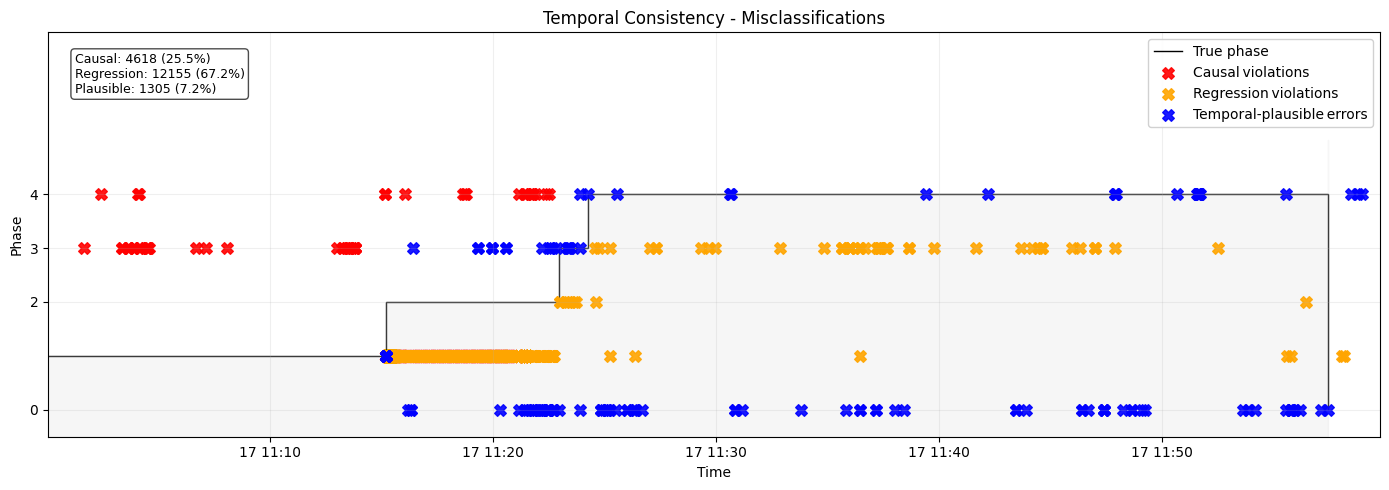

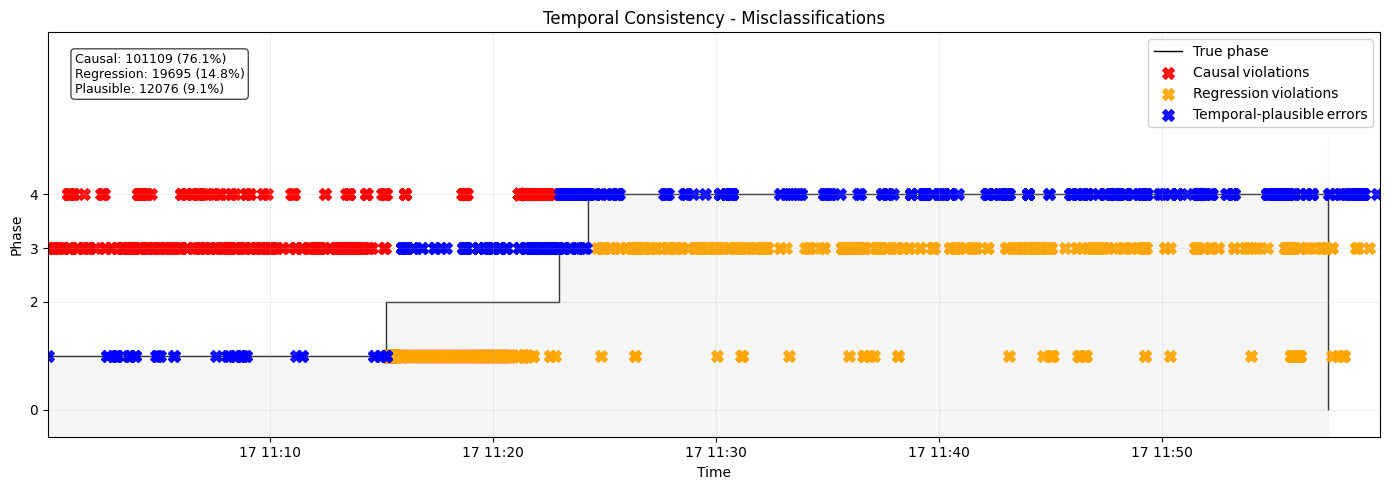

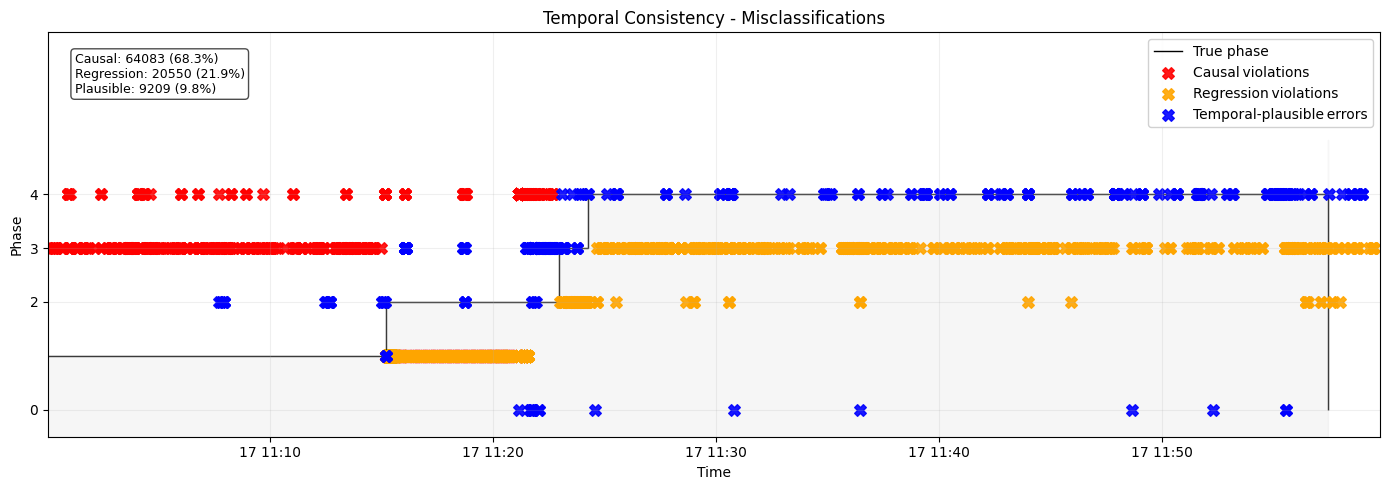

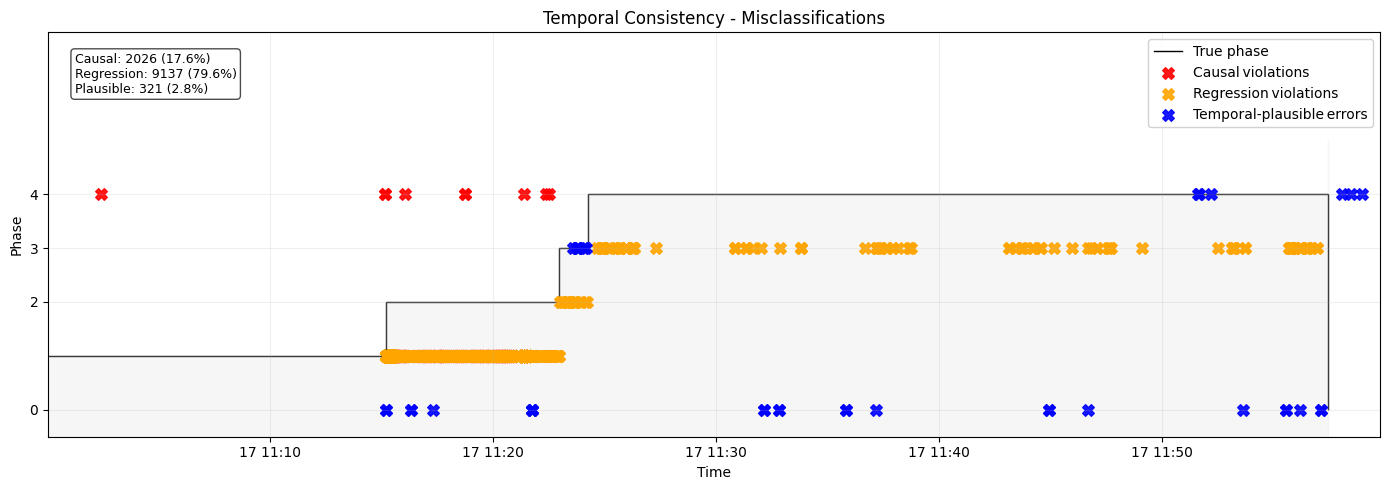

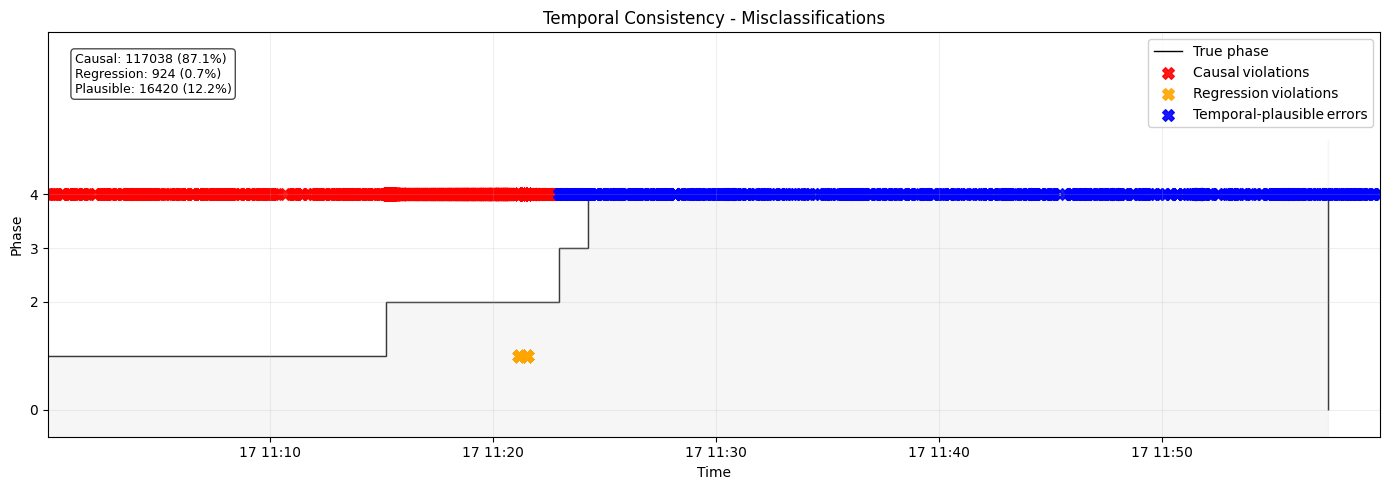

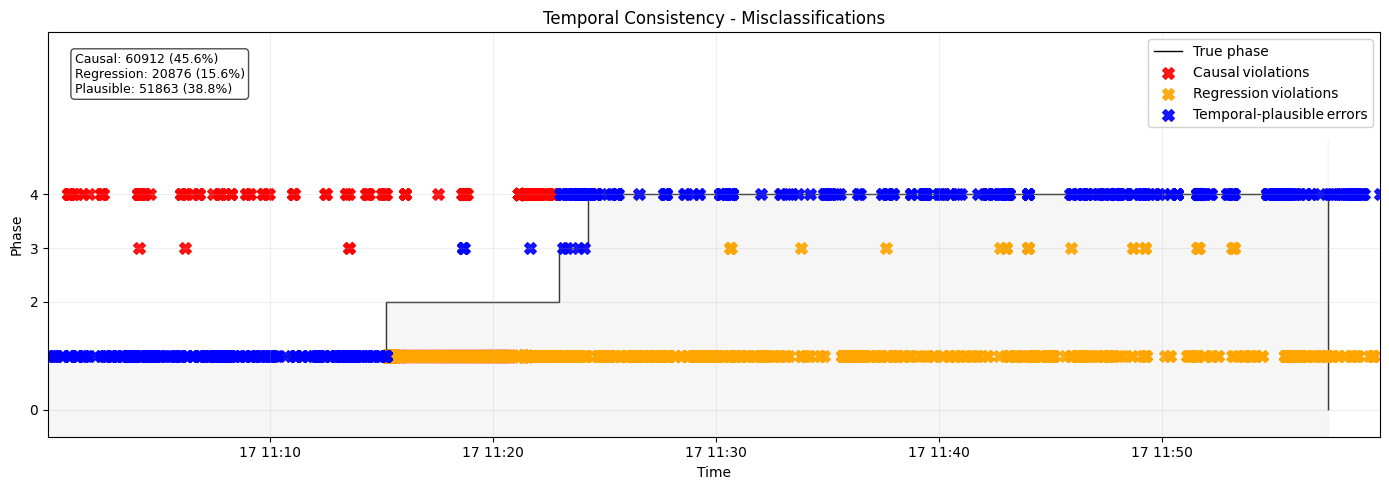

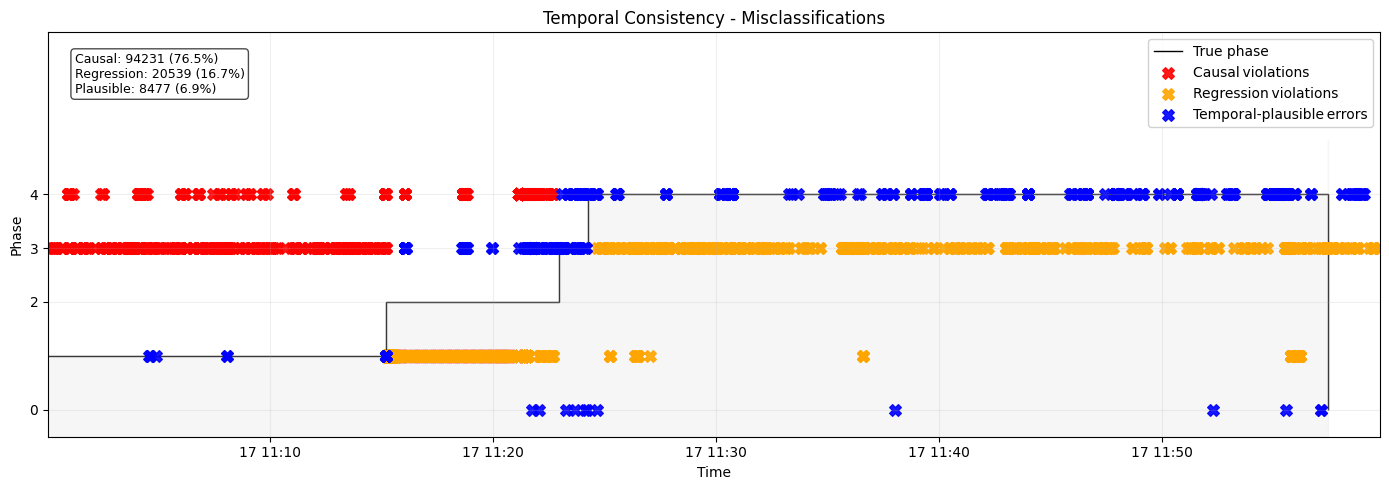

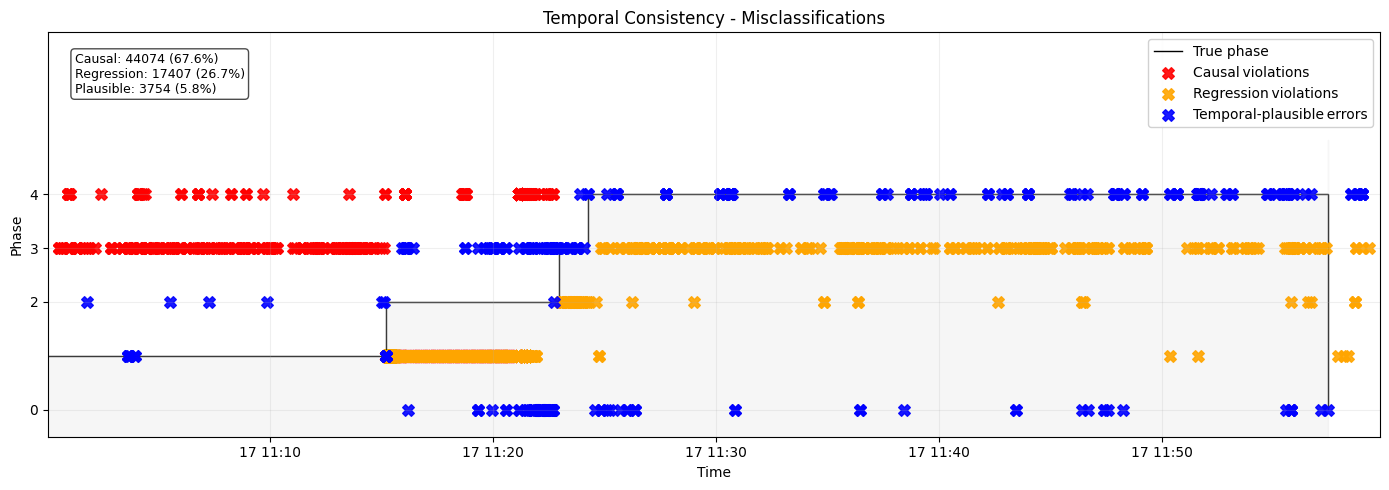

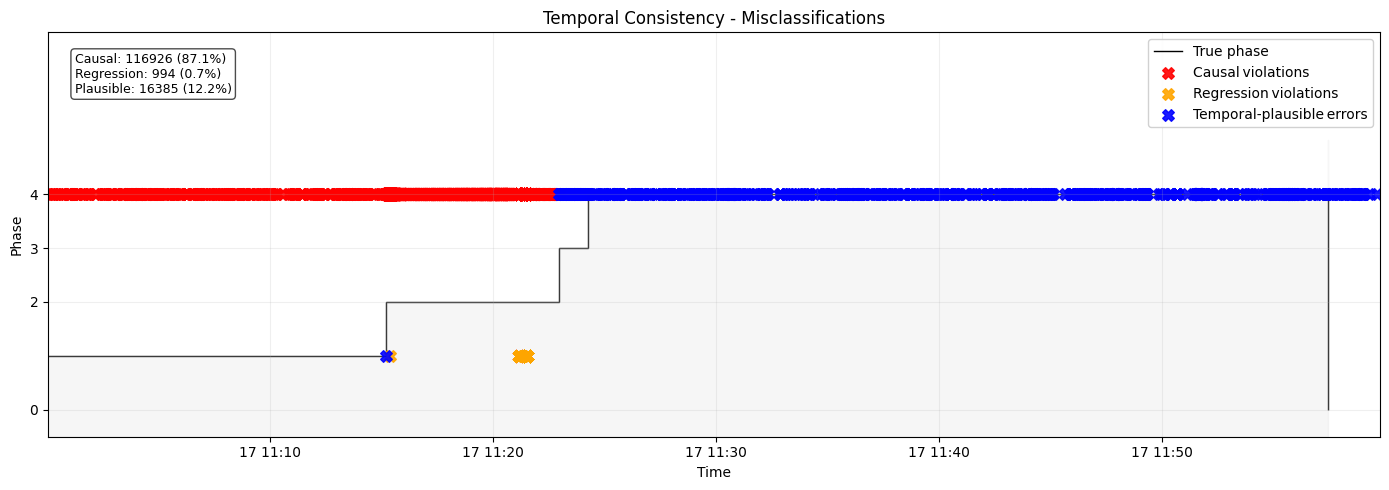

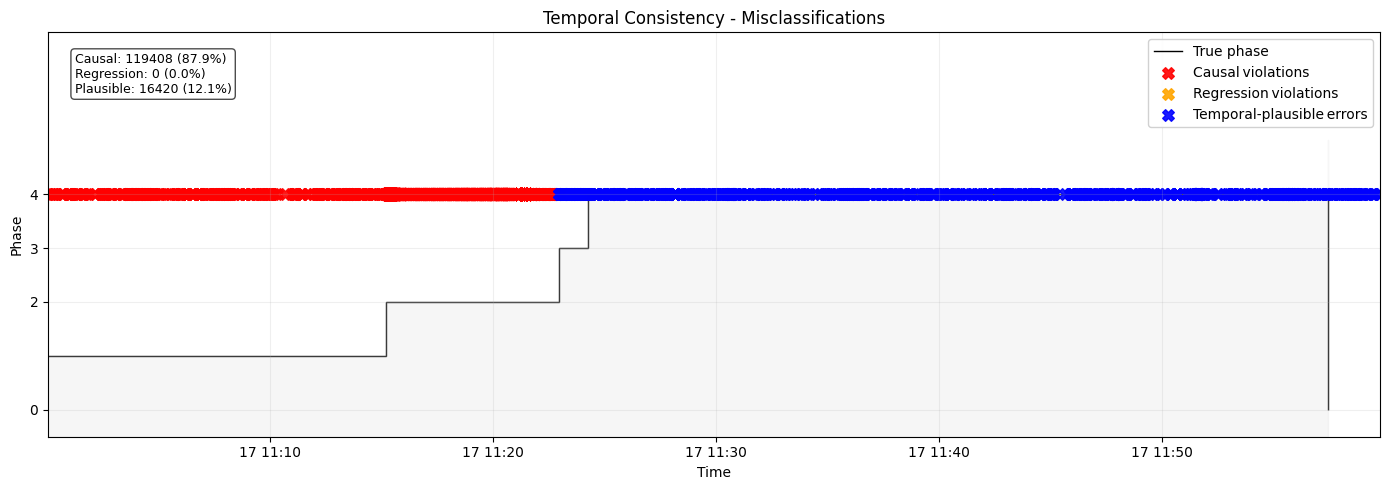

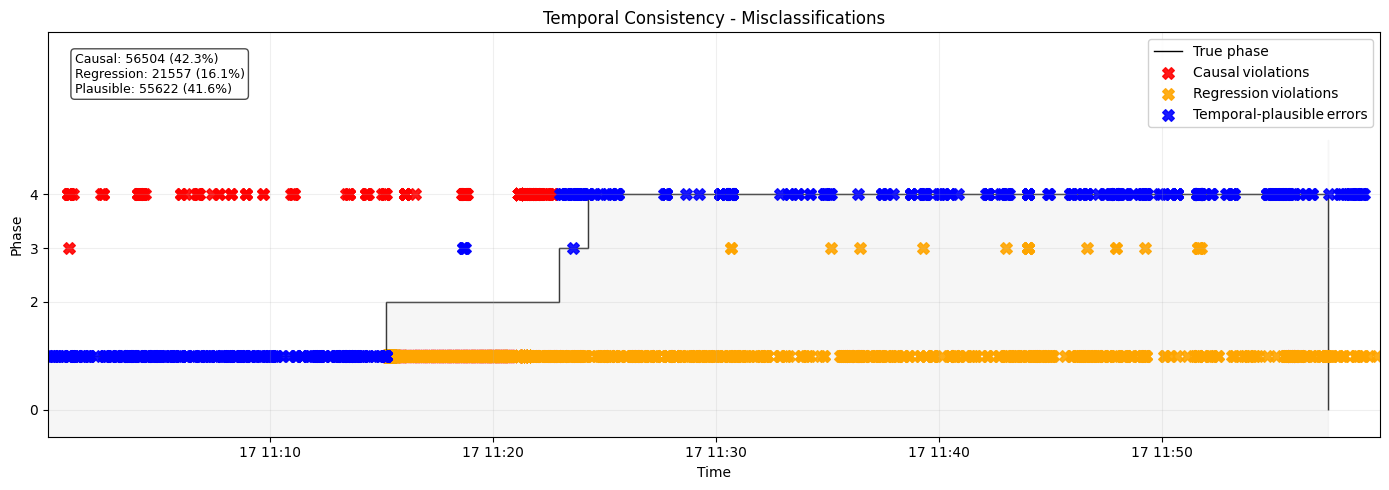

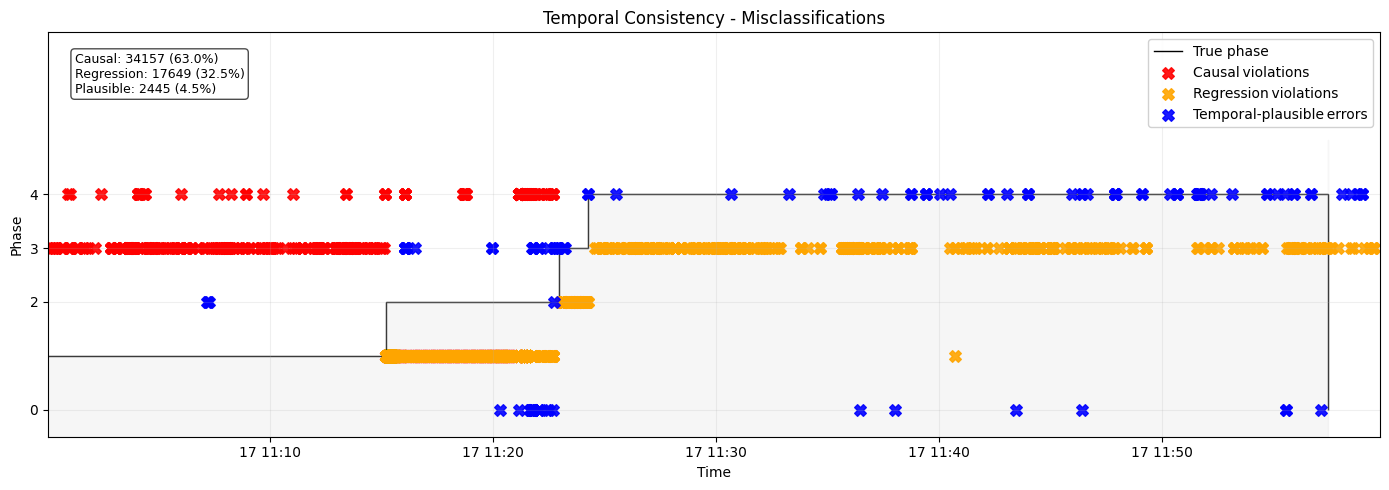

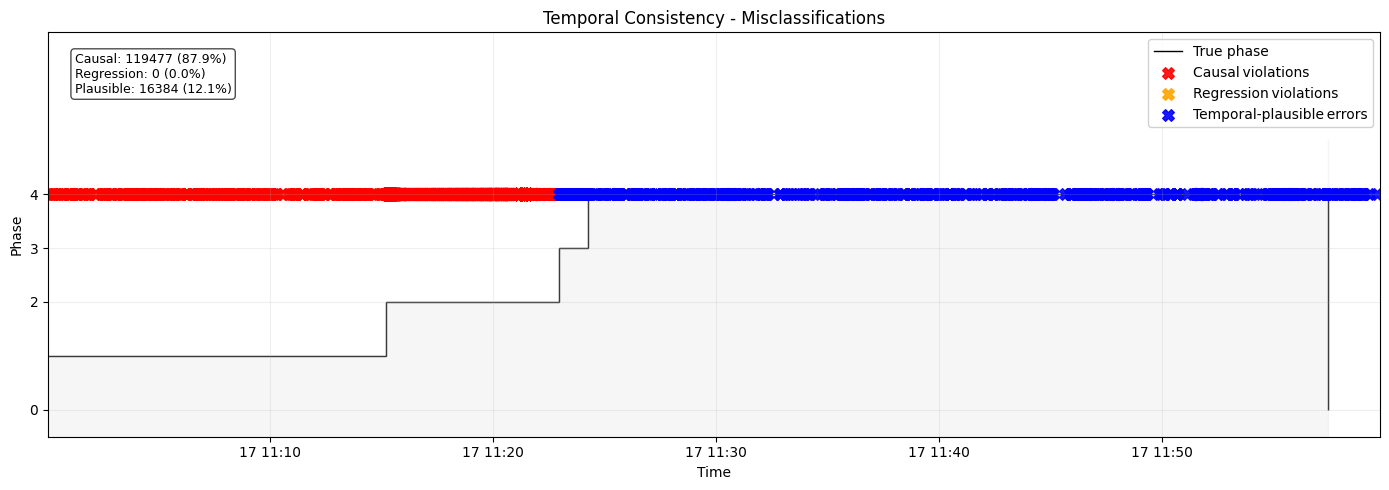

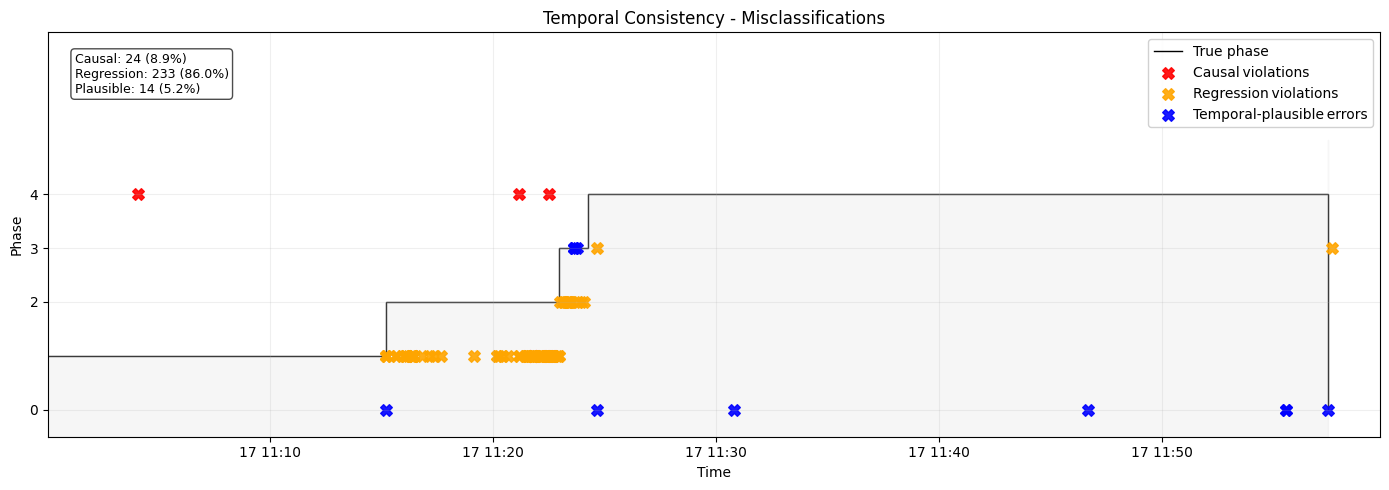

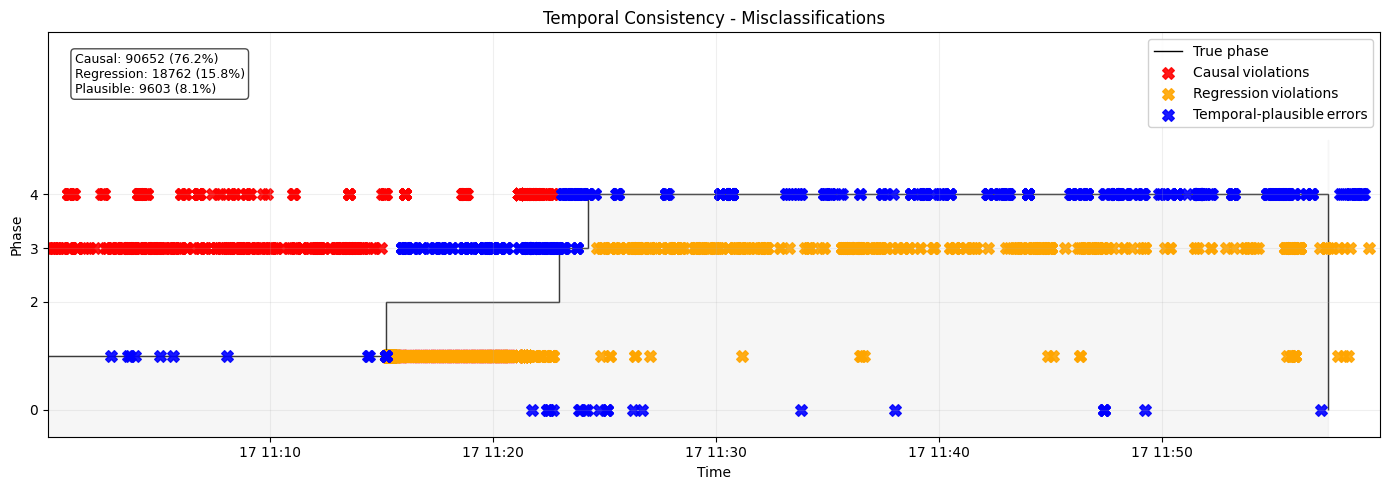

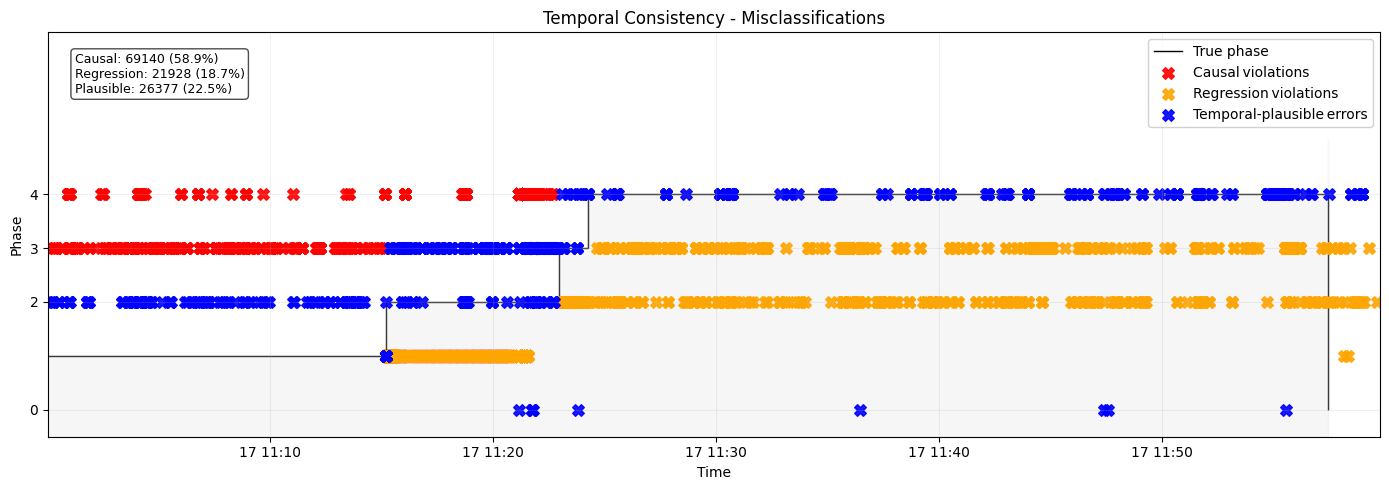

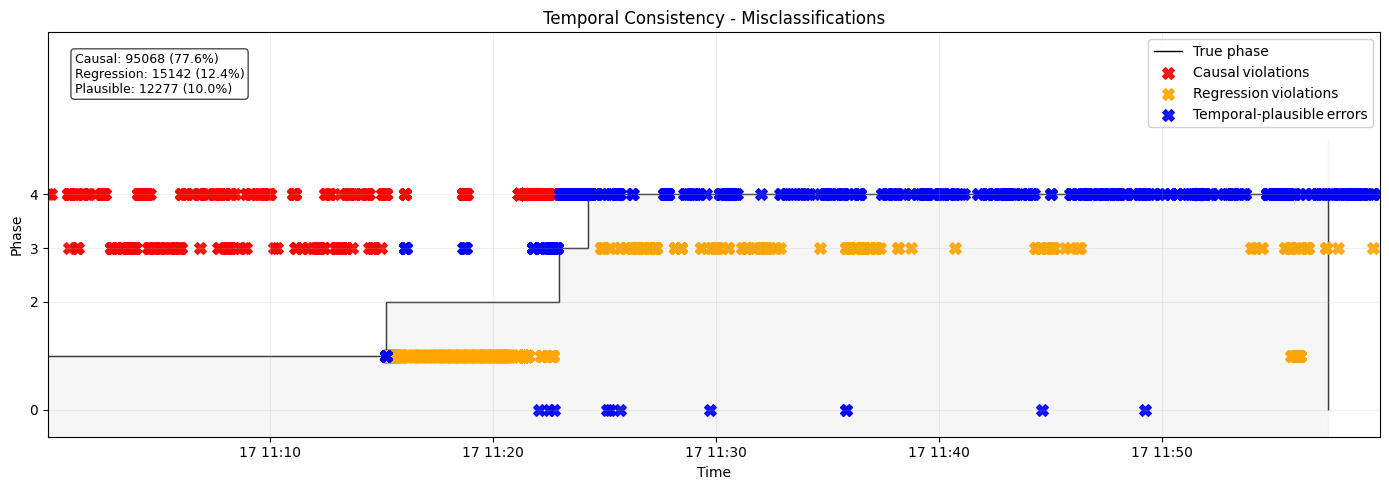

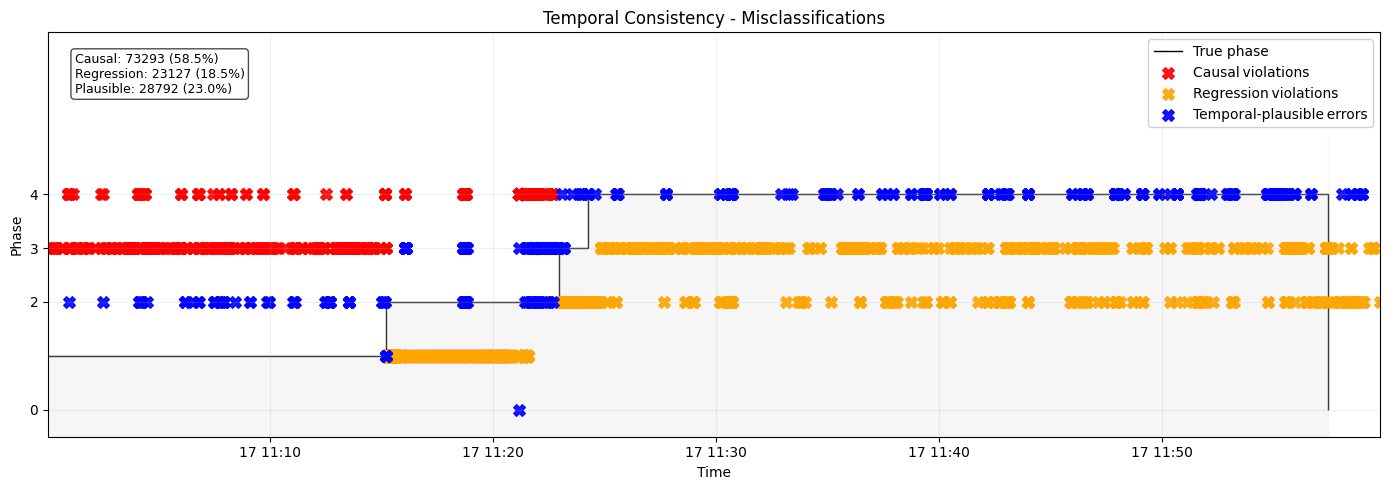

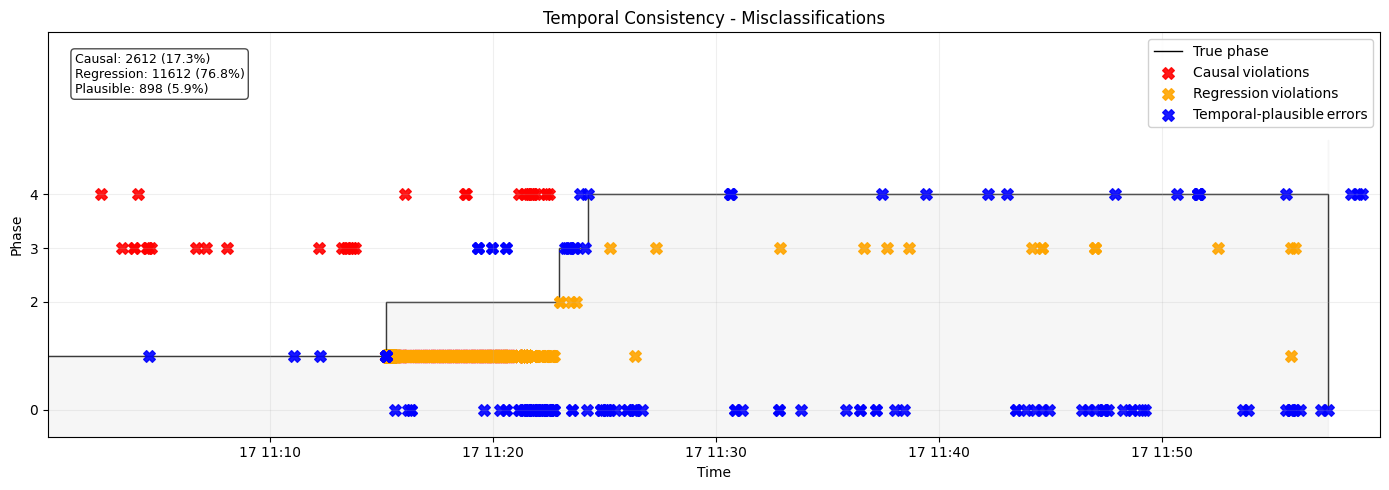

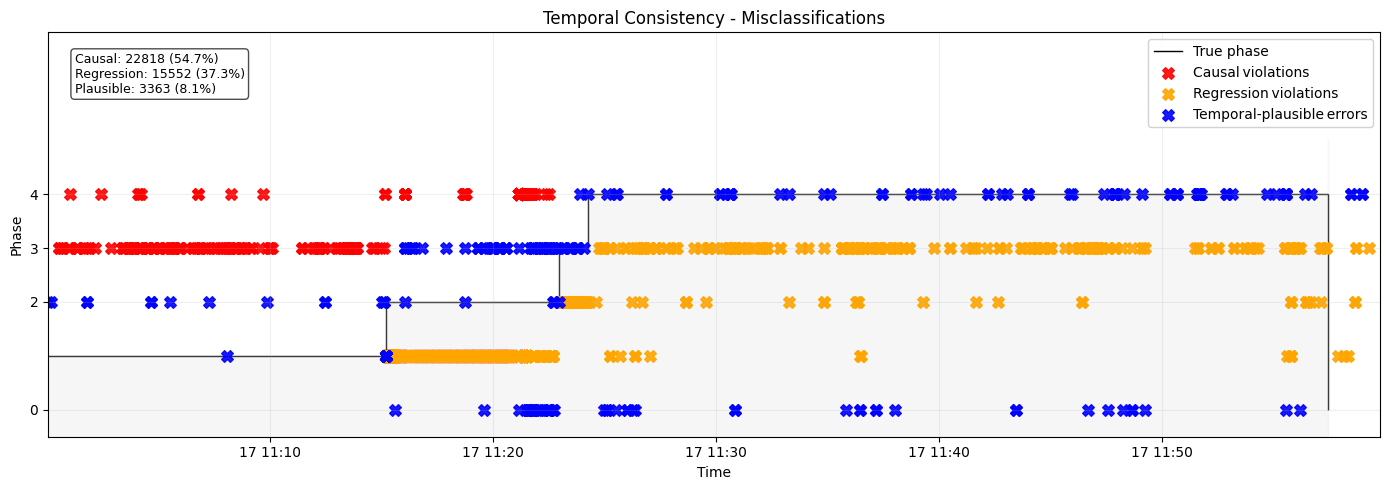

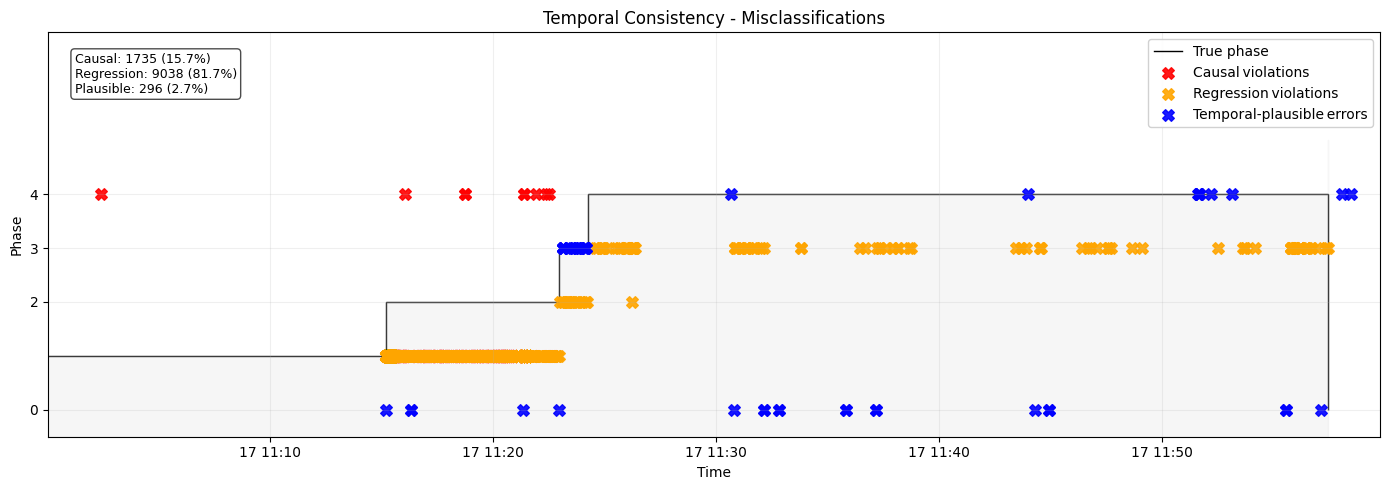

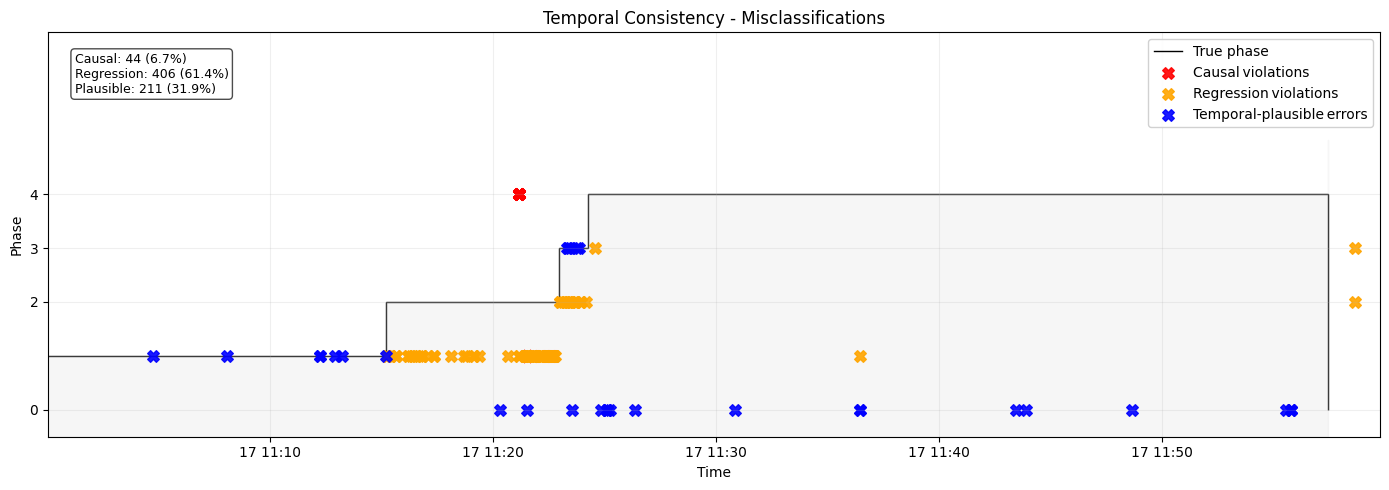

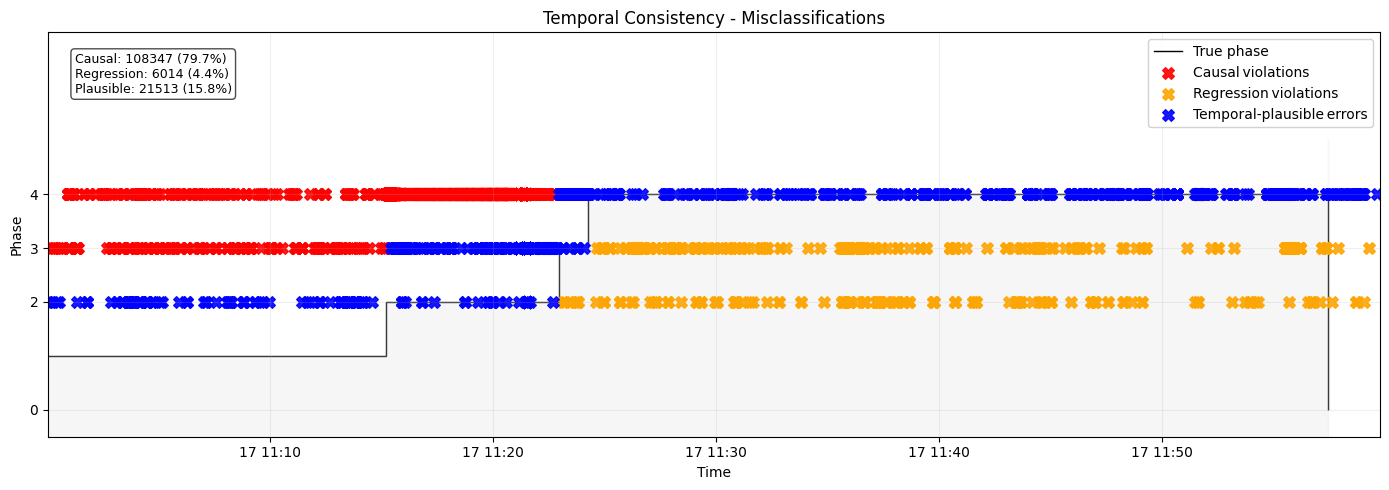

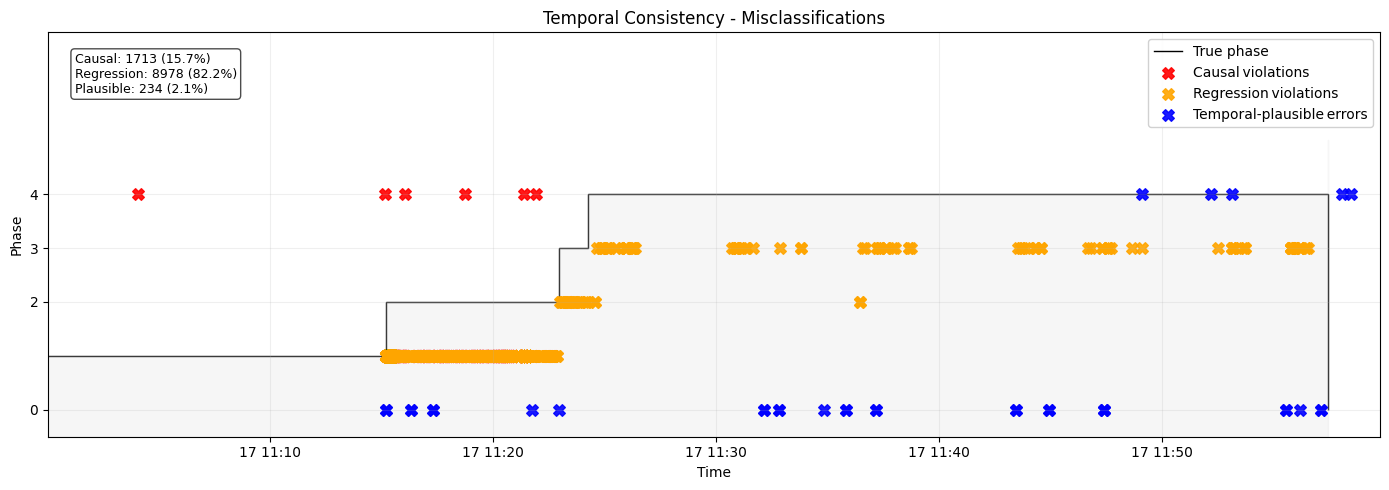

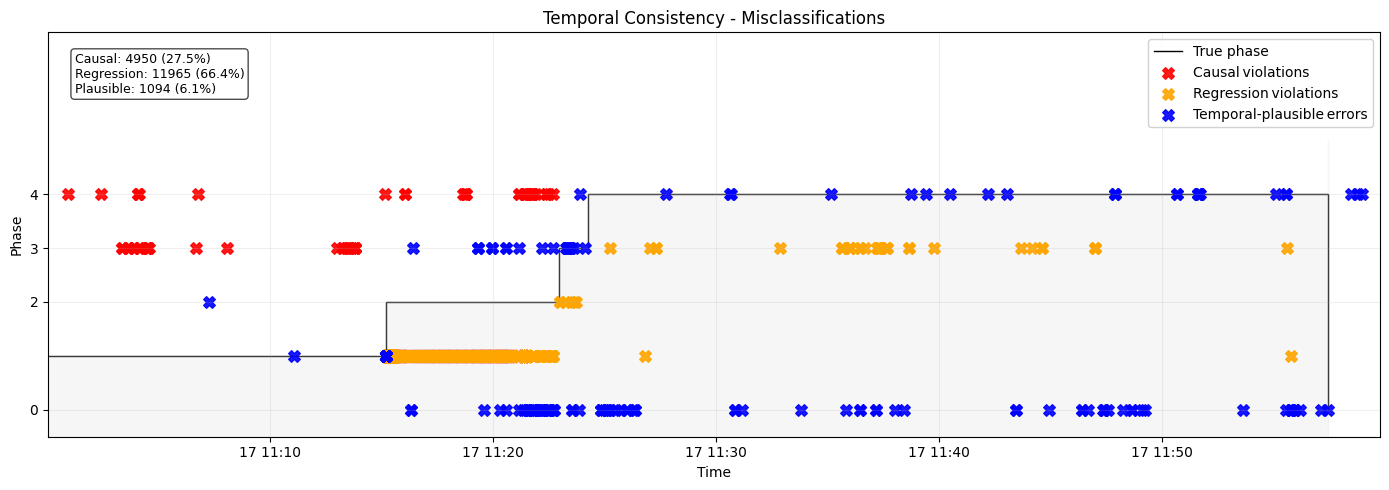

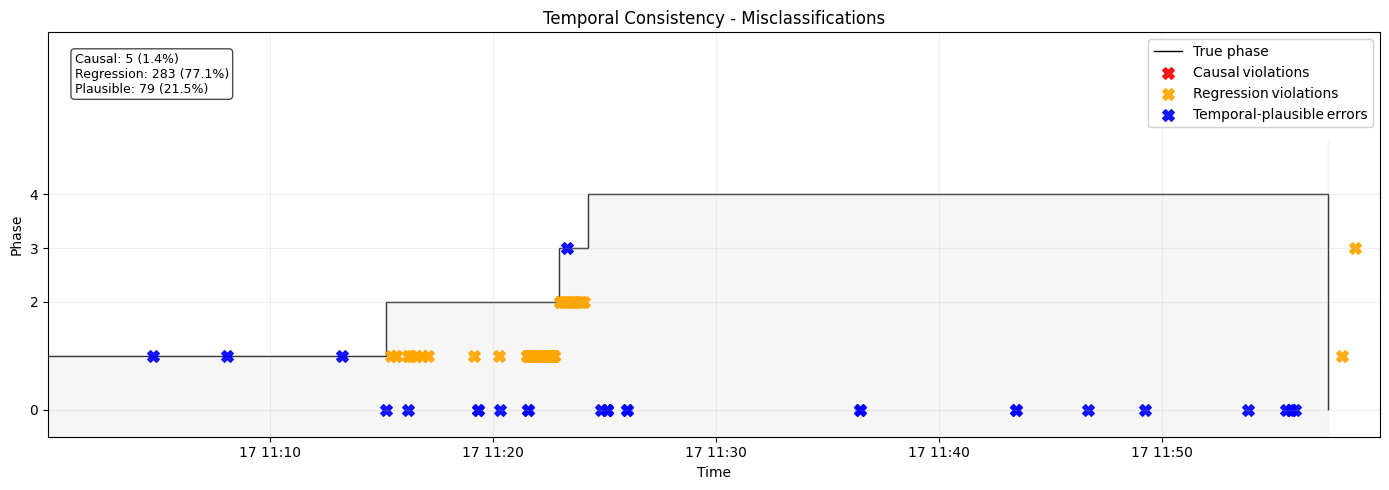

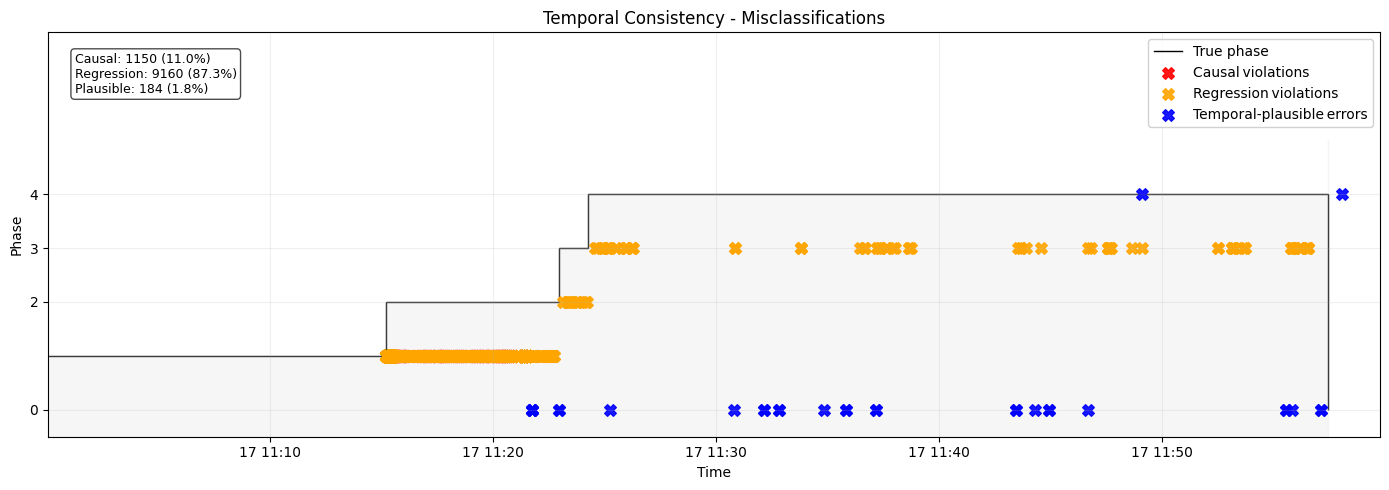

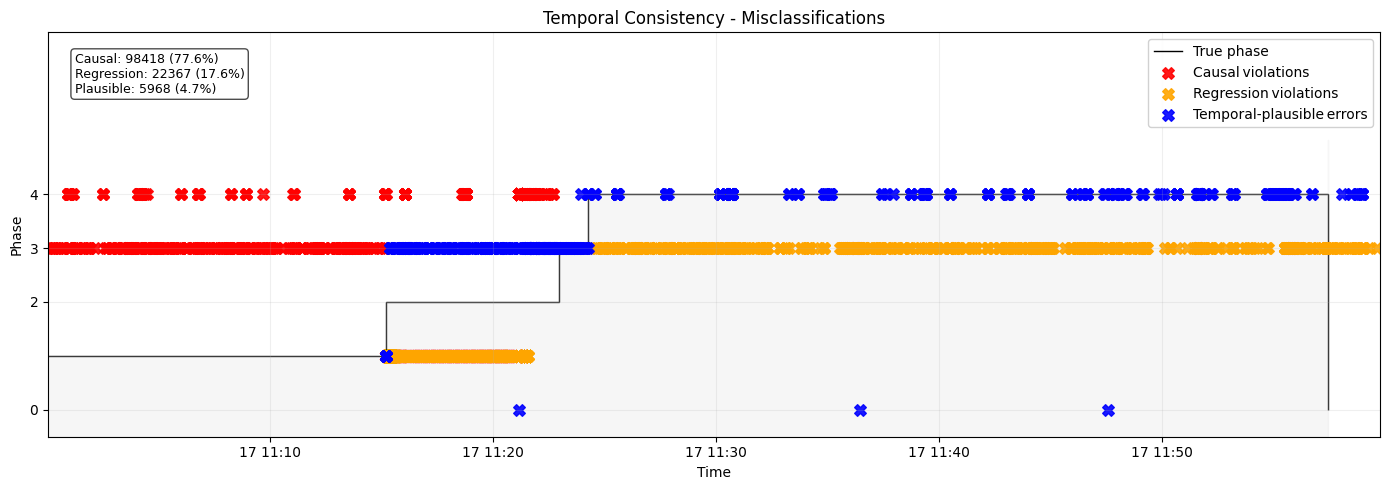

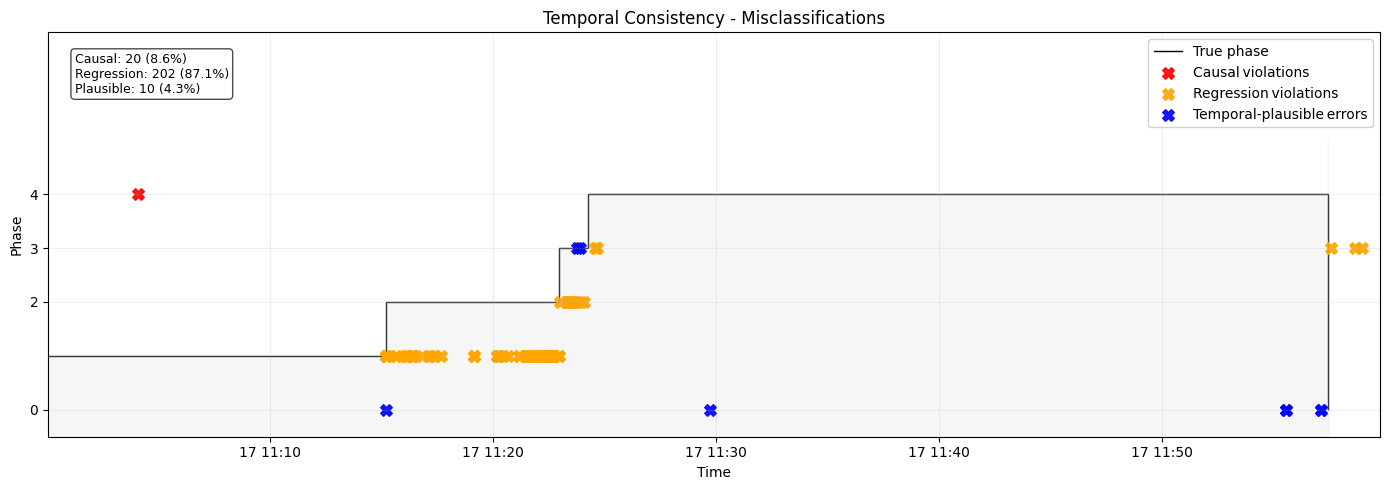

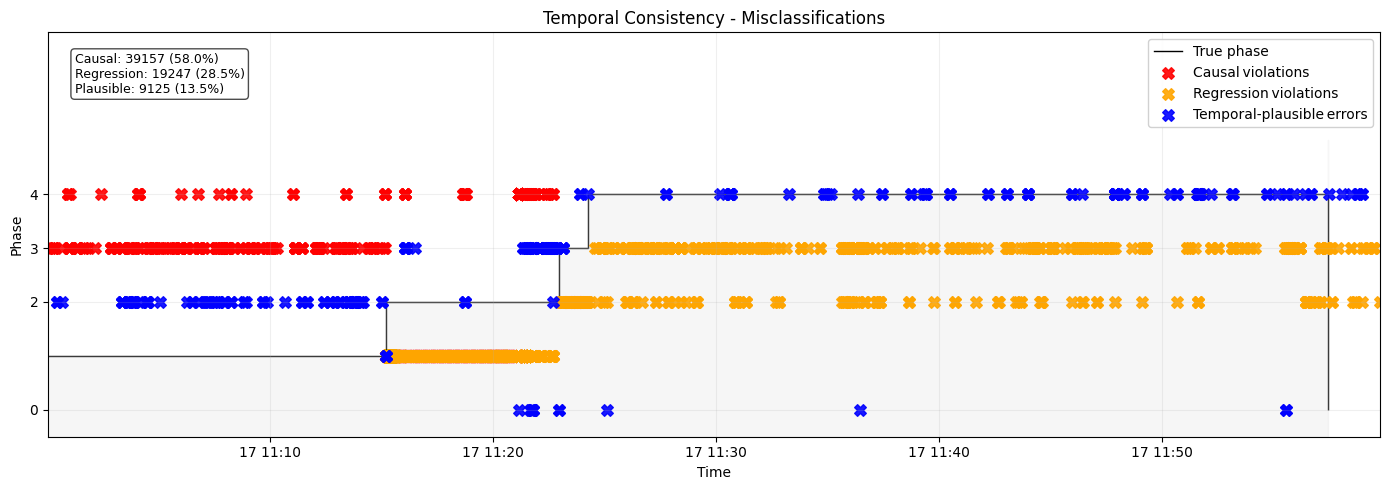

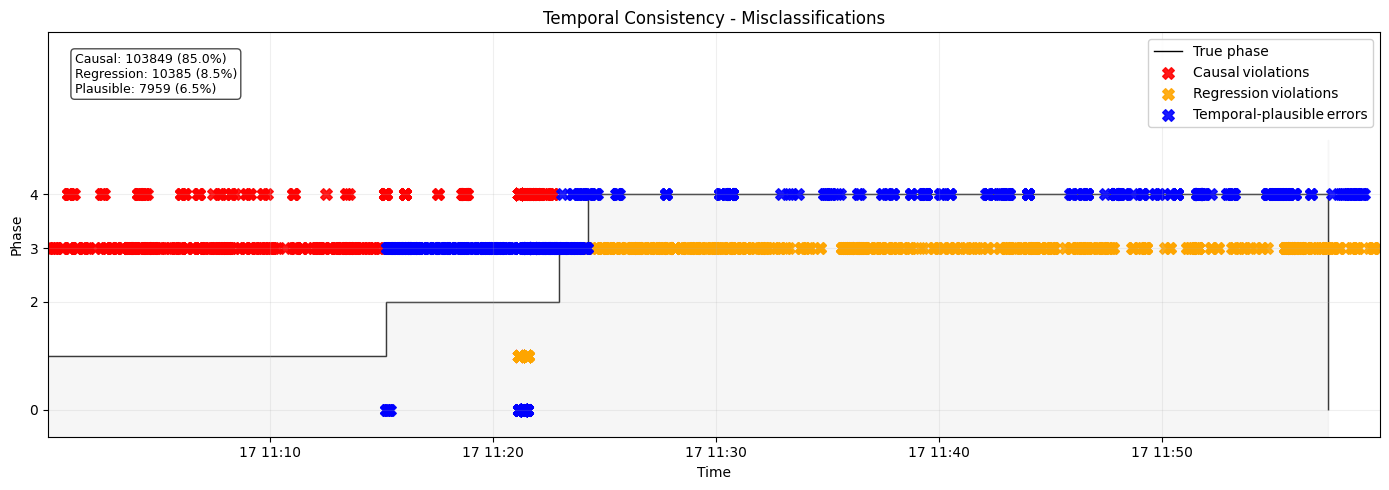

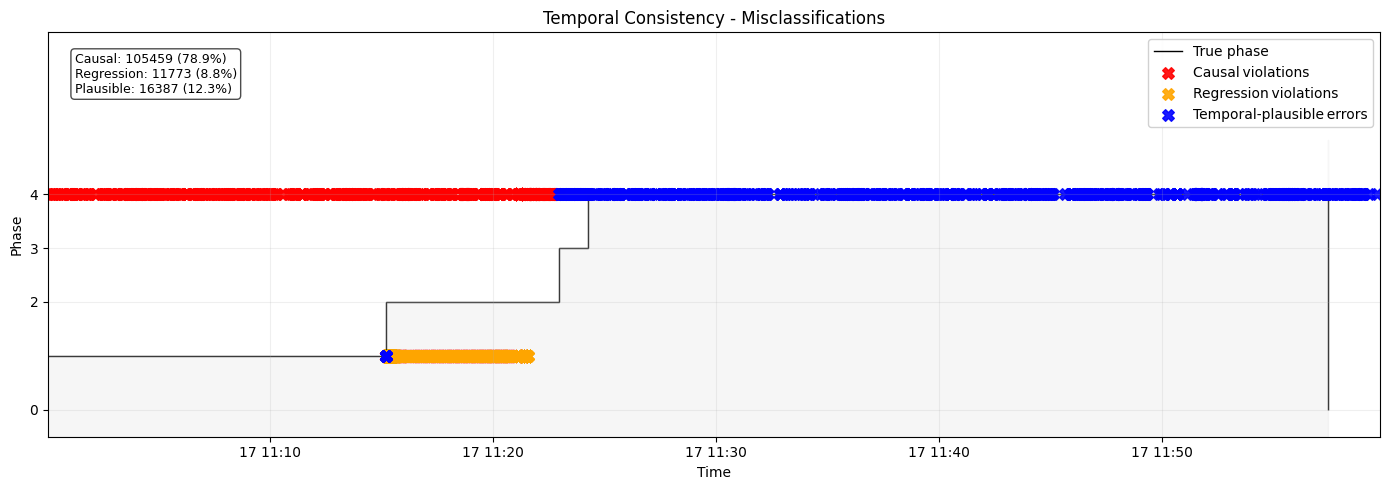

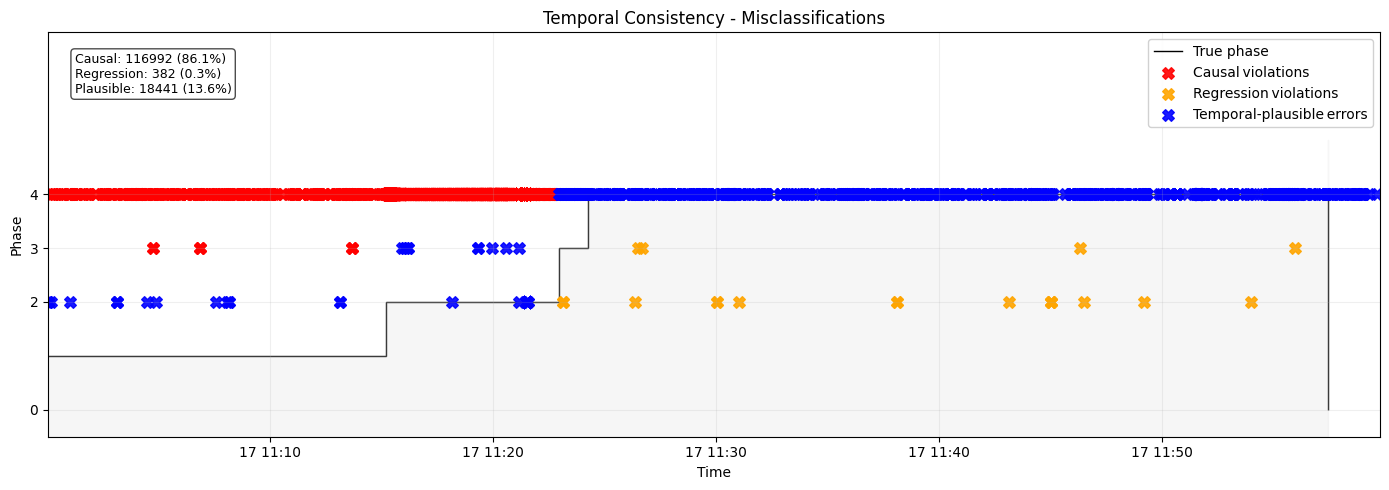

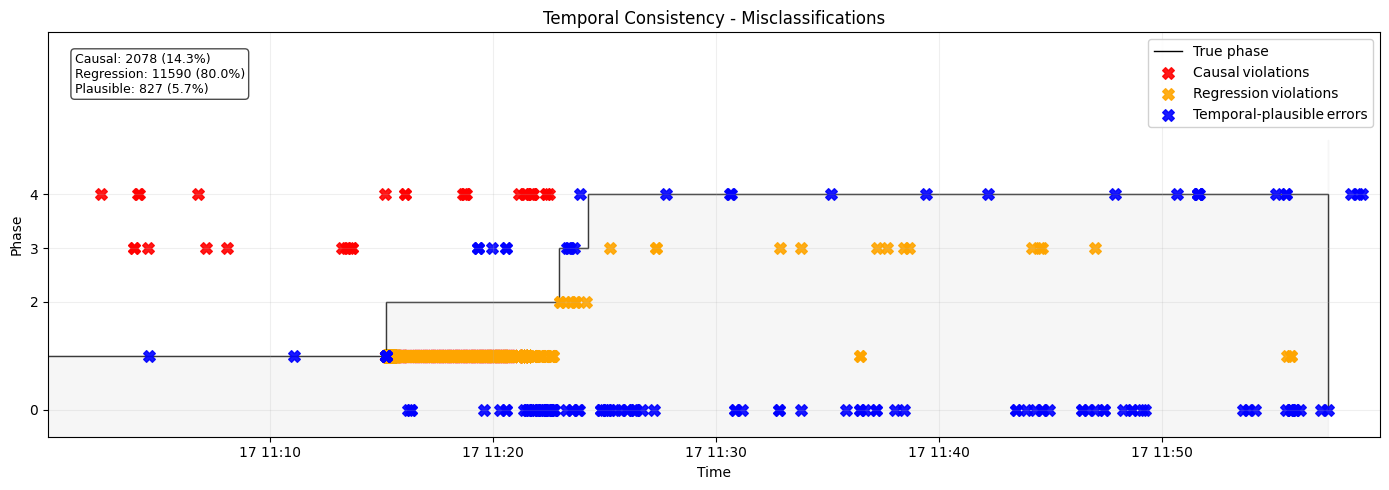

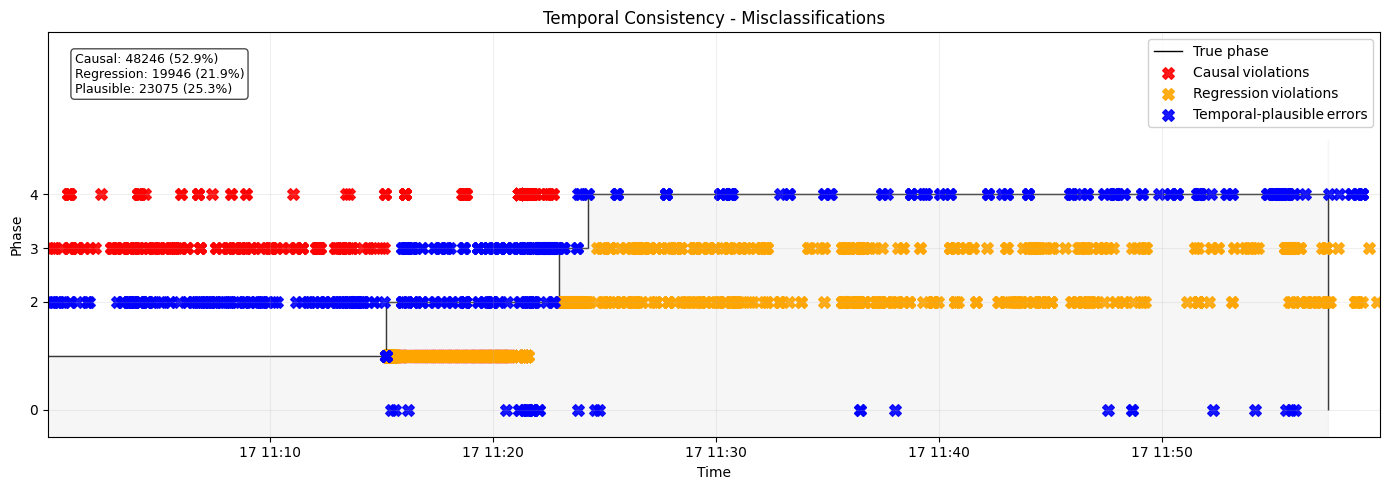

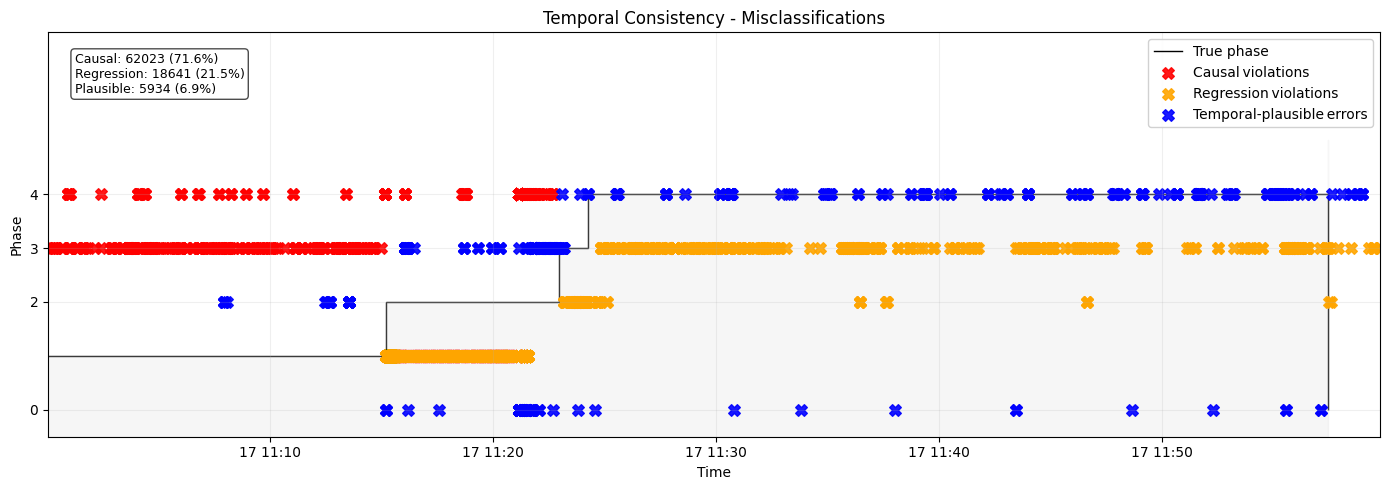

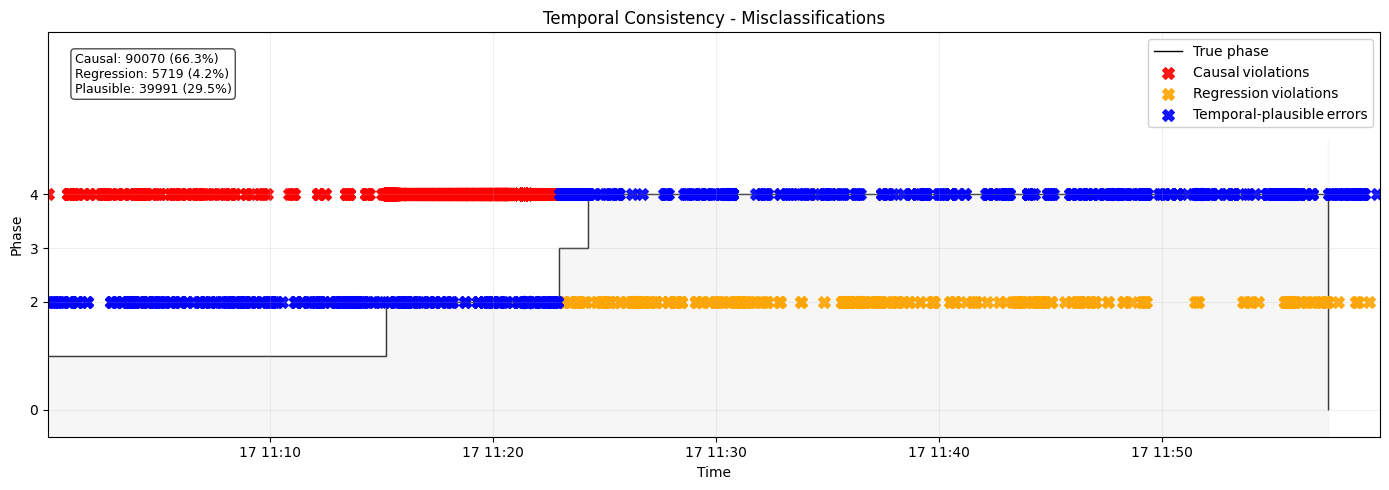

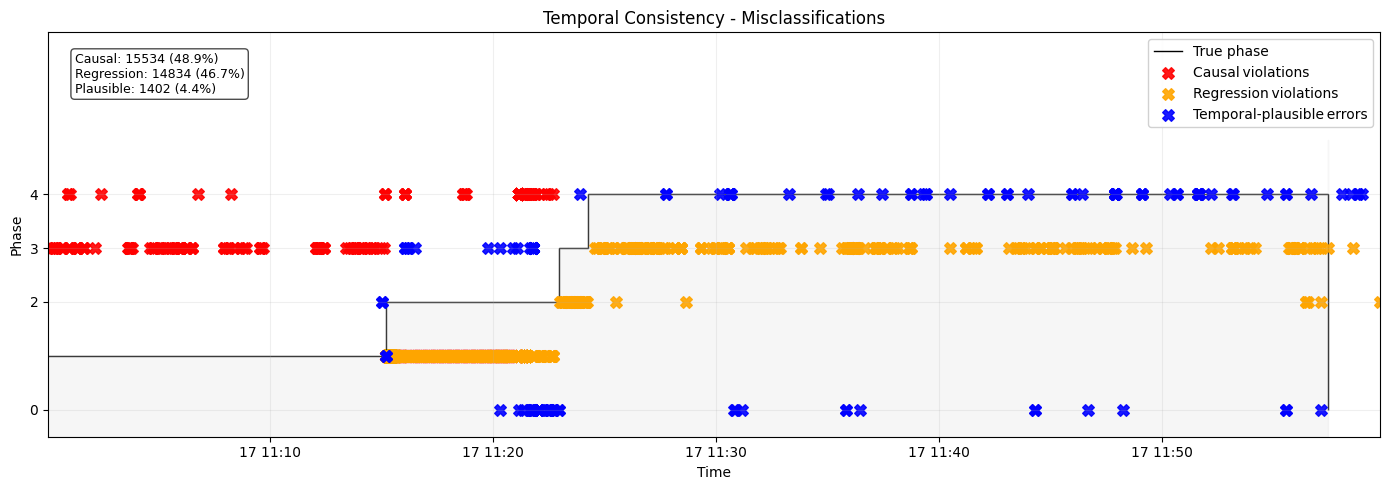

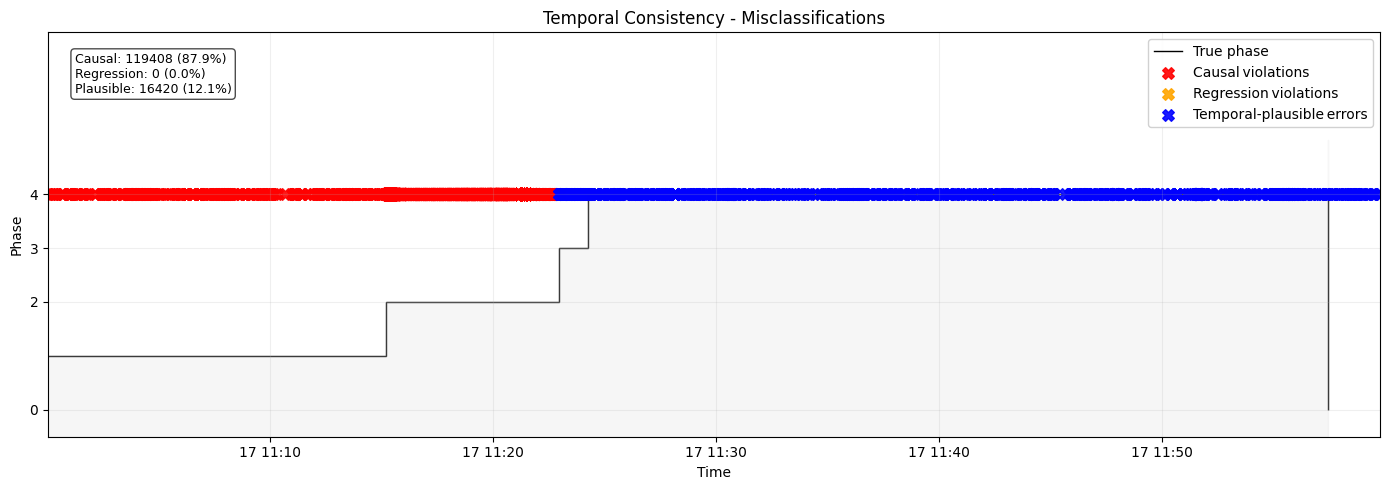

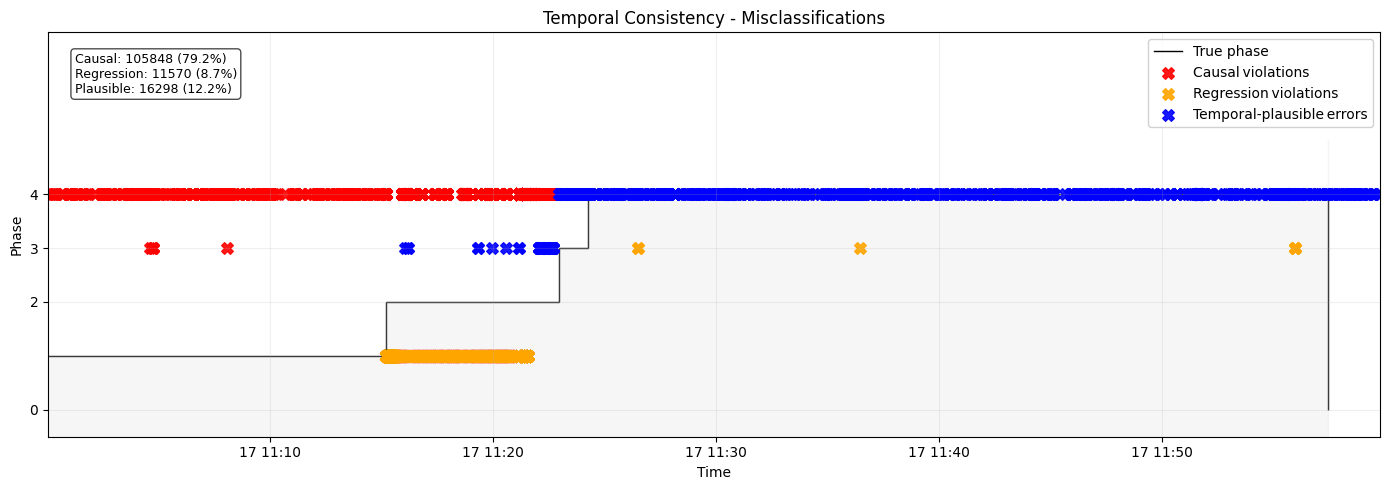

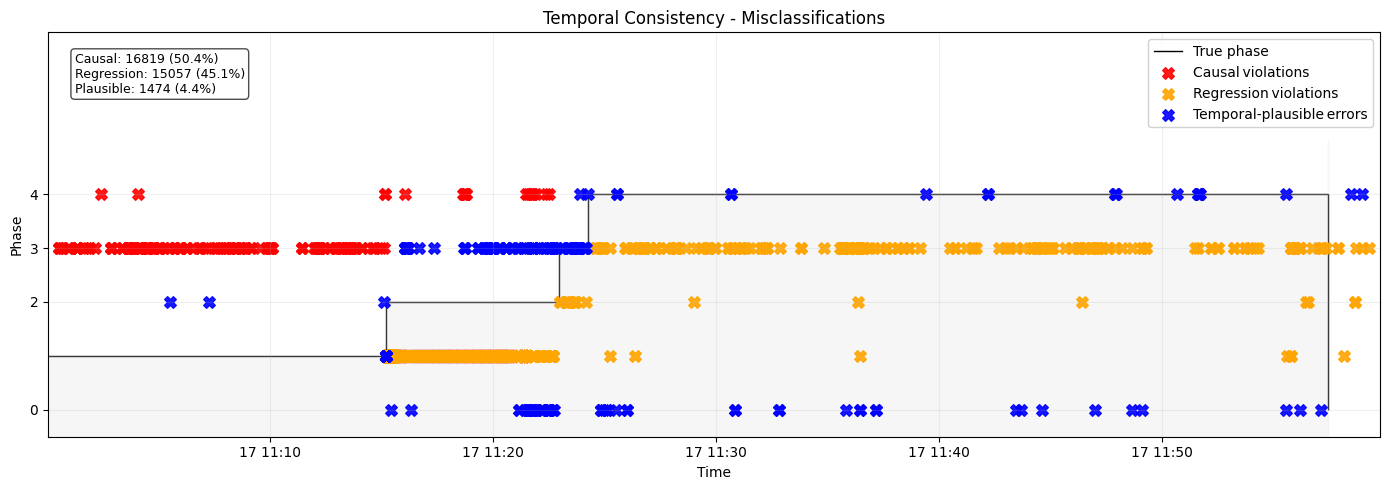

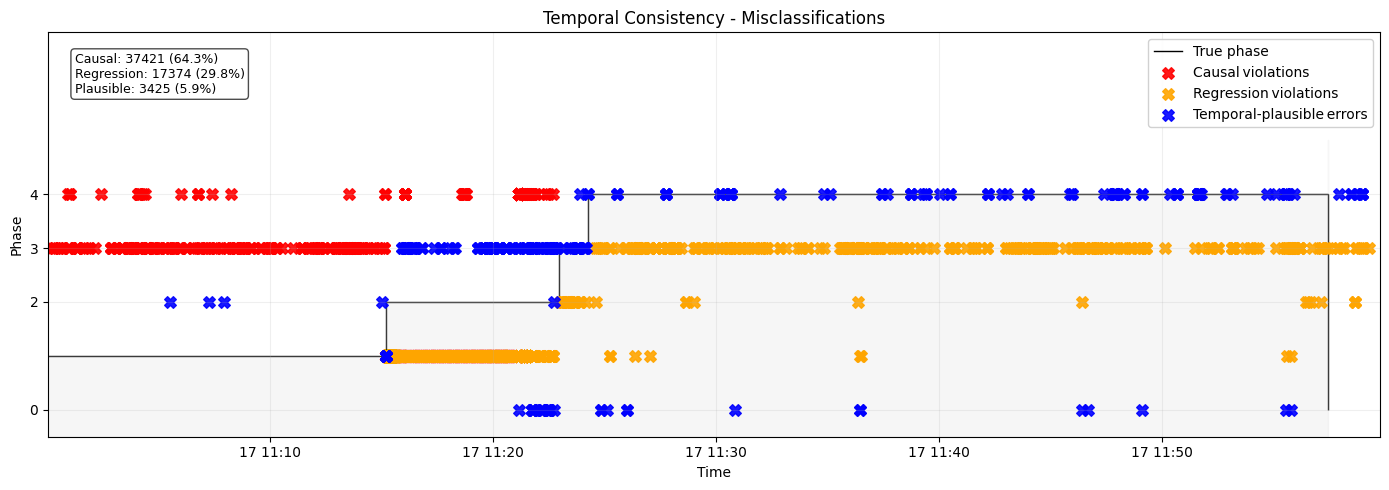

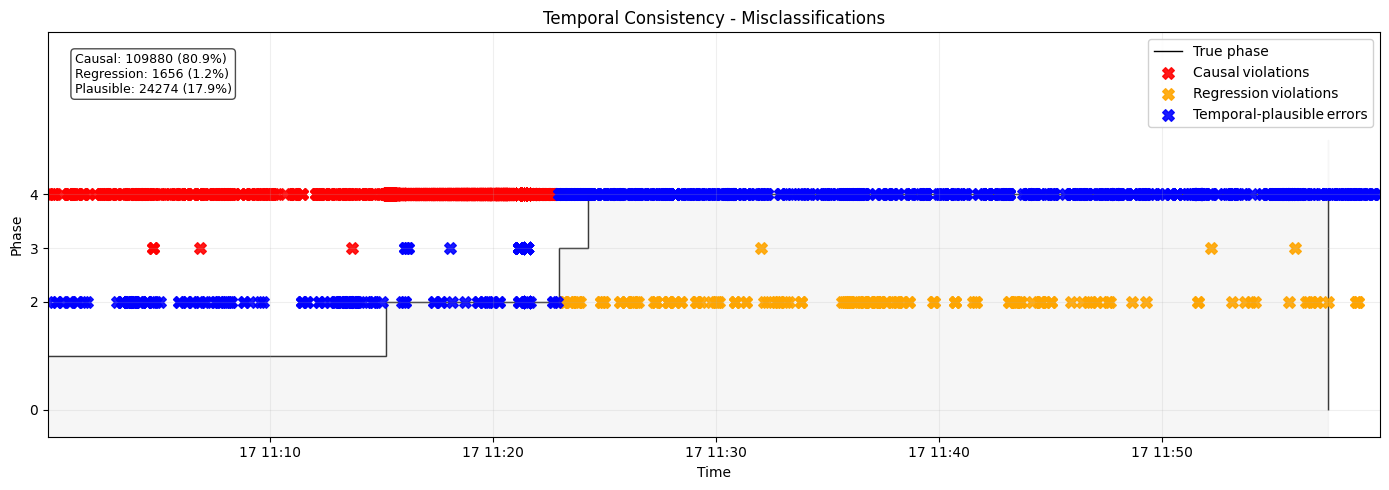

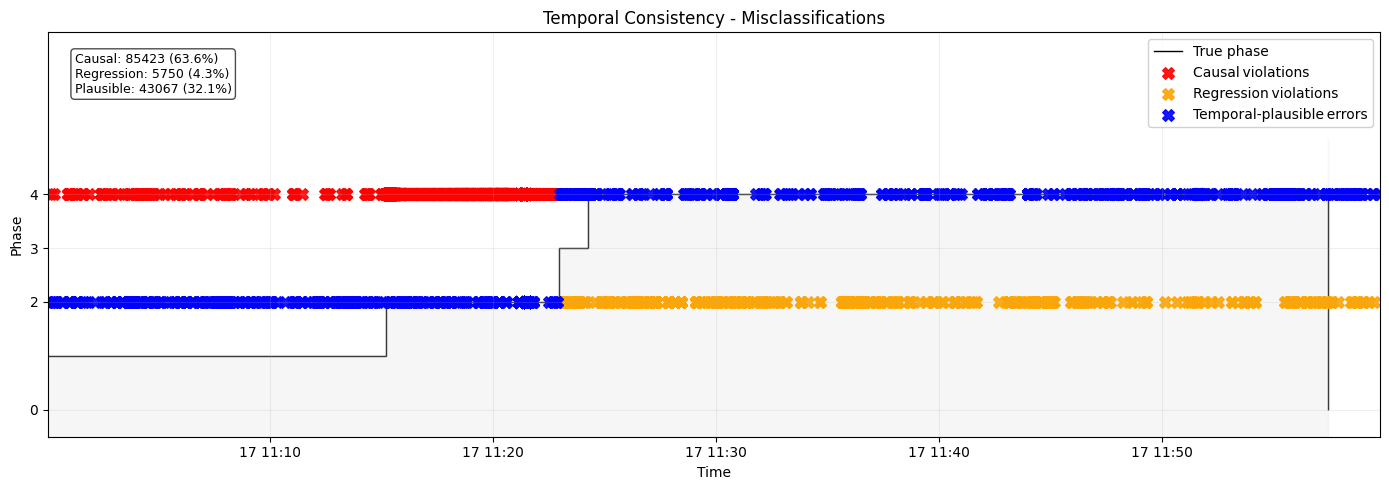

In [ ]:
results = []

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem

    if "multiclass" in experiment_name:
        model = "multiclass"
    elif "ensemble" in experiment_name:
        model = "ensemble"
    
    if not ("aug" and "full") in experiment_name:
        continue

    print(f"Processing {experiment_name}...")

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    misclassified = df.iloc[real_flow_indices].copy()
    misclassified["y_true"] = metrics["y_true"]
    misclassified["y_pred"] = metrics["y_pred"]

    # --- Compute violation categories ---
    f1 = metrics["Macro F1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["Accuracy"],
        "precision" : metrics["Macro Precision"],
        "recall" : metrics["Macro Recall"], 
        "f1": metrics["Macro F1"],
        "FPR": metrics["False Alarm Rate"],
        "FNR": metrics["Detection Rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    plot_dir = out_dir / "temp_plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    # Create plots
    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name, 
        out_dir = plot_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )

## Create Metrics File

In [20]:
results_df = pd.DataFrame(results)

In [21]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"{out_dir}/metrics.csv",
    index=False
)

In [22]:
results_df_sorted_f1.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
28,ensemble_aug_w100_full,0.998355,0.763793,0.948513,0.826444,0.001662,0.998934,232,20,202,10,0.086207,0.870690,0.043103,0.609203
13,multiclass_aug_w100_full,0.998079,0.735316,0.946220,0.798918,0.001939,0.998668,271,24,233,14,0.088561,0.859779,0.051661,0.582681
25,ensemble_aug_w10_full,0.997385,0.728288,0.922909,0.786436,0.002553,0.996539,367,5,283,79,0.013624,0.771117,0.215259,0.625400
21,multiclass_aug_w10_full,0.995308,0.695040,0.924839,0.763093,0.004739,0.996273,661,44,406,211,0.066566,0.614221,0.319213,0.606966
26,ensemble_full_w100_full,0.925606,0.558506,0.890635,0.643421,0.077379,0.978695,10494,1150,9160,184,0.109586,0.872880,0.017534,0.414052
20,multiclass_full_w100_full,0.921530,0.510400,0.906095,0.605844,0.081917,0.982954,11069,1735,9038,296,0.156744,0.816515,0.026741,0.364169
3,multiclass_reduced_w100_full,0.918581,0.502651,0.882732,0.595732,0.084957,0.981884,11484,2026,9137,321,0.176419,0.795629,0.027952,0.348397
23,ensemble_reduced_w100_full,0.922551,0.499106,0.908442,0.587340,0.080756,0.981620,10925,1713,8978,234,0.156796,0.821785,0.021419,0.344585
18,multiclass_full_w10_full,0.892803,0.422274,0.719989,0.477935,0.111228,0.965880,15122,2612,11612,898,0.172728,0.767888,0.059384,0.237993
33,ensemble_full_w10_full,0.897261,0.410468,0.713239,0.465945,0.106639,0.967755,14495,2078,11590,827,0.143360,0.799586,0.057054,0.234348


In [24]:
results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)

results_df_sorted_temp.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
25,ensemble_aug_w10_full,0.997385,0.728288,0.922909,0.786436,0.002553,0.996539,367,5,283,79,0.013624,0.771117,0.215259,0.625400
28,ensemble_aug_w100_full,0.998355,0.763793,0.948513,0.826444,0.001662,0.998934,232,20,202,10,0.086207,0.870690,0.043103,0.609203
21,multiclass_aug_w10_full,0.995308,0.695040,0.924839,0.763093,0.004739,0.996273,661,44,406,211,0.066566,0.614221,0.319213,0.606966
13,multiclass_aug_w100_full,0.998079,0.735316,0.946220,0.798918,0.001939,0.998668,271,24,233,14,0.088561,0.859779,0.051661,0.582681
26,ensemble_full_w100_full,0.925606,0.558506,0.890635,0.643421,0.077379,0.978695,10494,1150,9160,184,0.109586,0.872880,0.017534,0.414052
20,multiclass_full_w100_full,0.921530,0.510400,0.906095,0.605844,0.081917,0.982954,11069,1735,9038,296,0.156744,0.816515,0.026741,0.364169
3,multiclass_reduced_w100_full,0.918581,0.502651,0.882732,0.595732,0.084957,0.981884,11484,2026,9137,321,0.176419,0.795629,0.027952,0.348397
23,ensemble_reduced_w100_full,0.922551,0.499106,0.908442,0.587340,0.080756,0.981620,10925,1713,8978,234,0.156796,0.821785,0.021419,0.344585
18,multiclass_full_w10_full,0.892803,0.422274,0.719989,0.477935,0.111228,0.965880,15122,2612,11612,898,0.172728,0.767888,0.059384,0.237993
33,ensemble_full_w10_full,0.897261,0.410468,0.713239,0.465945,0.106639,0.967755,14495,2078,11590,827,0.143360,0.799586,0.057054,0.234348
